In [ ]:
# Step 1 : Import the neseccery libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical




In [ ]:
# Step 2 : Importing the data set
(x_train, y_train), (x_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train.shape, x_test.shape # traning-> 60k images, 28 x 28(height and width)

((60000, 28, 28), (10000, 28, 28))

In [ ]:
# Grey scale -->(samples, height, width, channels)
#  -1 = auto dimension calculate korar shortcut
x_train = x_train.reshape(-1, 28, 28, 1) / 255   # we want all the value 0 to 1 between lie
x_test = x_test.reshape(-1, 28, 28, 1) / 255

In [ ]:
# 5 - > [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]  that is work on probablity value
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
y_train.shape

(60000, 10)

In [ ]:
# Step 3 : Build the Model
model = Sequential([
    Conv2D(8, (3, 3), activation =  'relu', input_shape = (28, 28, 1)),
    MaxPooling2D(),
    Flatten(),
    Dense(10, activation = 'softmax')

])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Step 4 : model compile (Forword propogation and Back propogation)
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
# step 5 : Model train
model.fit(x_train, y_train, epochs = 1)  # how to get 1875 ->> 60k/batch_size = default(32) >> 60k/32 = 1875

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9143 - loss: 0.3038


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


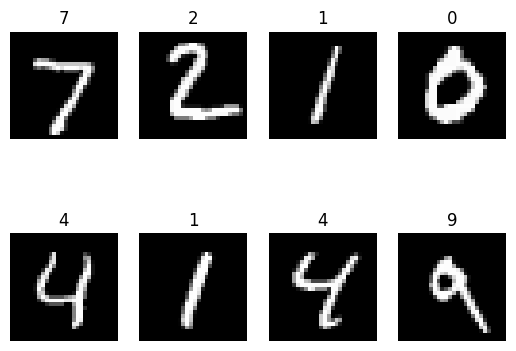

In [ ]:
#Step 6 : prediction visulisation
import matplotlib.pyplot as plt
pred = model.predict(x_test[ : 8]) # 0 to 7
for i in range(8):
  plt.subplot(2, 4, i+1)
  plt.imshow(x_test[i], cmap = 'grey')
  plt.title(pred[i].argmax())
  plt.axis('off')
plt.show()
